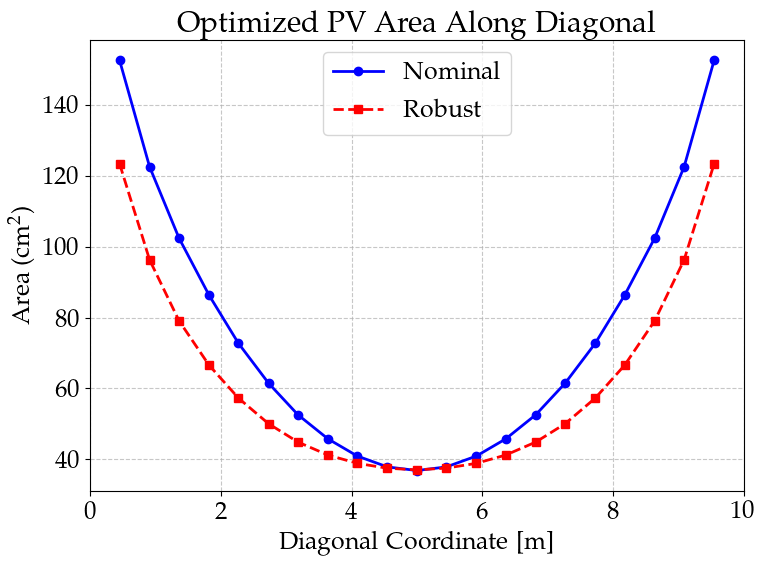

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 18,
    "lines.linewidth": 2,
})

# 1. Load results
results_nom = np.load("area_only_cma_results_A1_eight.npy", allow_pickle=True)
results_rob = np.load("robust_minimax_results_A1.npy")  # [X,Y,Z,...,Area(m2),...]

# 2. Extract coordinates and areas
x_nom = np.array([res['pos'][0] for res in results_nom])
areas_nom = np.array([res['area_cm2'] for res in results_nom])

x_rob = results_rob[:, 0]
areas_rob = results_rob[:, 5] * 1e4   # m² → cm²

# 3. Sort for clean lines
idx_nom = np.argsort(x_nom)
idx_rob = np.argsort(x_rob)

# 4. Plot
plt.figure(figsize=(8,6))

plt.plot(x_nom[idx_nom], areas_nom[idx_nom],
         marker='o', linestyle='-', color='blue', label='Nominal')

plt.plot(x_rob[idx_rob], areas_rob[idx_rob],
         marker='s', linestyle='--', color='red', label='Robust')

plt.xlabel(r'Diagonal Coordinate [m]')
plt.ylabel(r'Area (cm$^2$)')
plt.title(r'Optimized PV Area Along Diagonal')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

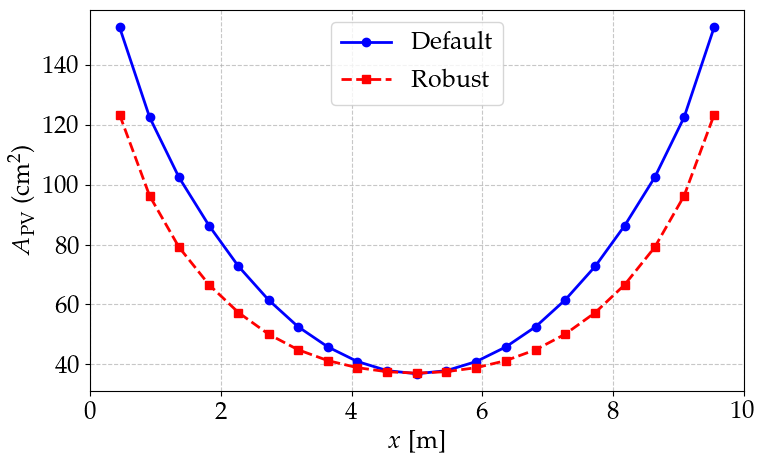

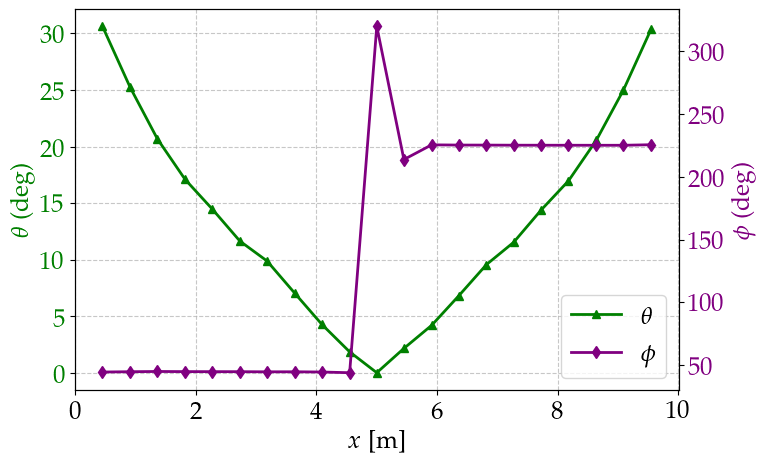

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 18,
    "lines.linewidth": 2,
})

# ---- Nominal data ----
x_nom = np.array([res['pos'][0] for res in results_nom])
areas_nom = np.array([res['area_cm2'] for res in results_nom])

# ---- Robust data ----
x_rob = results_rob[:, 0]
theta_rob = np.degrees(results_rob[:, 3])
phi_rob = np.degrees(results_rob[:, 4])
areas_rob = results_rob[:, 5] * 1e4  # m² → cm²

# ---- Sort for clean curves ----
idx_nom = np.argsort(x_nom)
idx_rob = np.argsort(x_rob)

x_nom = x_nom[idx_nom]
areas_nom = areas_nom[idx_nom]

x_rob = x_rob[idx_rob]
areas_rob = areas_rob[idx_rob]
theta_rob = theta_rob[idx_rob]
phi_rob = phi_rob[idx_rob]

# =========================
# ---- Plot 1: Area ----
# =========================
fig1, ax_area = plt.subplots(figsize=(8, 5))

ax_area.plot(x_nom, areas_nom,
             marker='o', linestyle='-', color='blue', label='Default')
ax_area.plot(x_rob, areas_rob,
             marker='s', linestyle='--', color='red', label='Robust')

ax_area.set_ylabel(r'$A_\mathrm{PV}$ (cm$^2$)')
ax_area.set_xlabel(r'$x$ [m]')
ax_area.grid(True, linestyle='--', alpha=0.7)
ax_area.legend(loc='best', frameon=True)

plt.tight_layout()
plt.savefig("area_opt_A1.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close(fig1)


# =========================
# ---- Plot 2: Theta & Phi ----
# =========================
fig2, ax_theta = plt.subplots(figsize=(8, 5))

# Theta (left y-axis)
line_theta = ax_theta.plot(x_rob, theta_rob,
                           marker='^', linestyle='-', color='green',
                           label=r'$\theta$')
ax_theta.set_ylabel(r'$\theta$ (deg)', color='green')
ax_theta.tick_params(axis='y', labelcolor='green')
ax_theta.set_xlabel(r'$x$ [m]')
ax_theta.grid(True, linestyle='--', alpha=0.7)

# Phi (right y-axis)
ax_phi = ax_theta.twinx()
line_phi = ax_phi.plot(x_rob, phi_rob,
                       marker='d', linestyle='-', color='purple',
                       label=r'$\phi$')
ax_phi.set_ylabel(r'$\phi$ (deg)', color='purple')
ax_phi.tick_params(axis='y', labelcolor='purple')

lines = line_theta + line_phi
labels = [l.get_label() for l in lines]
ax_theta.legend(lines, labels, loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig("theta_phi_opt_A1.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close(fig2)

In [3]:
(areas_nom - areas_rob)/areas_nom *100

array([19.15040209, 21.4477618 , 22.80915061, 22.91513823, 21.28420562,
       18.64399612, 14.68475255,  9.98747901,  5.02705787,  0.97142274,
       -0.51345344,  0.88207939,  5.02705717,  9.98780167, 14.68665502,
       18.6439614 , 21.28403189, 22.91517459, 22.81286242, 21.45284789,
       19.15581113])

In [7]:
(area_rob - area_cma)/area_cma * 100

array([0.38266505, 0.37640568, 0.38969085, 0.36266265, 0.37569167,
       0.37404818, 0.34612836, 0.36125101, 0.35443137, 0.27695179,
       0.51345344, 0.41464275, 0.35338865, 0.36089124, 0.34389071,
       0.37409101, 0.37570278, 0.3626153 , 0.38486349, 0.36990653,
       0.37594921])